In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots render inline and look reasonably clean by default
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)  # show all columns, don't truncate

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Note: SeniorCitizen is already numeric, not a Yes/No string

Unlike Partner, Dependents, PhoneService, and PaperlessBilling — which are
Yes/No strings — `SeniorCitizen` is stored as integer 0/1 directly. This
means it won't need any encoding in Phase 2; it's already in the correct
format for modeling.

In [28]:
# Number of customers and features(rows and columns)
print("Shape:", df.shape)
print()

# Column Datatypes
print("Dtypes:")
print(df.dtypes)
print()

# Missing Values
print("Missing values per column:")
print(df.isnull().sum())
print()

# Duplicate Rows
print("Duplicate rows:", df.duplicated().sum())
print()

# Duplicate Customer Id's
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

Shape: (7043, 21)

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract     

In [29]:
# Customer Churn
print(df['Churn'].value_counts())
print()

# Normalized Customer Churn 
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


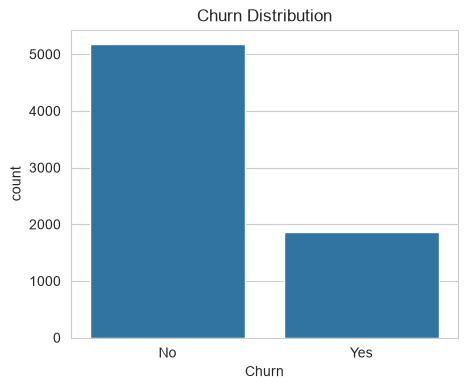

In [30]:
# Visualize Customer Churn
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()

## Finding: Significant class imbalance in target variable

The target variable `Churn` is imbalanced:
- No (did not churn): 5174 customers (~73.5%)
- Yes (churned): 1869 customers (~26.5%)

**Why this matters:** A model that simply predicts "No" for every customer
would score ~73.5% accuracy without learning anything useful. This means
accuracy alone will be a misleading metric for this project — precision,
recall, F1-score, and ROC-AUC will matter more, since they account for
how well the model identifies the minority (churn) class specifically.
This also means we may need to consider class balancing techniques
(e.g. class weights, SMOTE) during model training in a later phase.

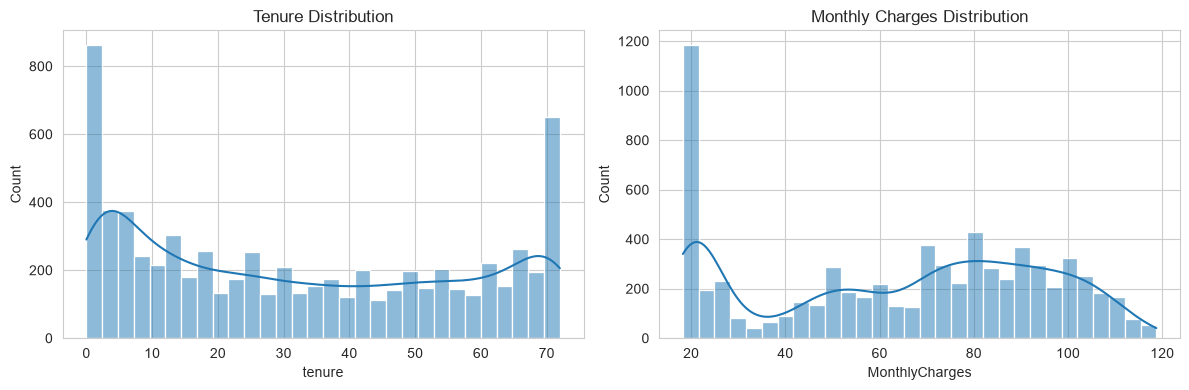

In [31]:
# Numeric feature distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of tenure - how long customers have stayed (in months)
sns.histplot(df['tenure'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Tenure Distribution')

# Histogram of MonthlyCharges - how much they pay per month
sns.histplot(df['MonthlyCharges'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Monthly Charges Distribution')

plt.tight_layout()
plt.show()

## Observation: Both numeric distributions are bimodal, not smooth

- **Tenure**: Sharp spikes near 0 months and near 70-72 months, with fewer
  customers in the middle. This suggests two distinct populations: customers
  who are brand new, and customers who have stayed for the long haul — rather
  than a steady, even mix of tenures.
- **MonthlyCharges**: A sharp spike around $20, plus a broader hump around
  $70-90. This suggests a low-cost tier (likely customers with minimal
  services, e.g. phone-only) alongside a separate cluster paying for
  bundled/premium services.

**Why this matters:** This hints the customer base isn't one uniform group —
it's likely segmented by service type and plan. This is worth keeping in mind
when we look at categorical features like `InternetService` and `Contract`
next, since they probably explain these spikes.

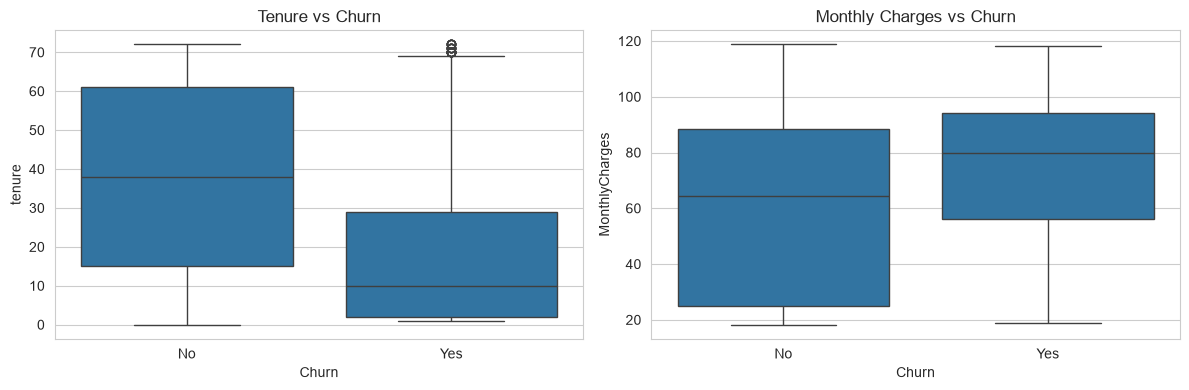

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot: tenure split by whether they churned or not
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title('Tenure vs Churn')

# Boxplot: MonthlyCharges split by churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

## Finding: Newer, higher-paying customers churn more

Comparing tenure and MonthlyCharges across churn status revealed a clear pattern:
- **Tenure**: Customers who churned have a noticeably *lower* median tenure
  than those who stayed — i.e. churn is more common among newer customers.
- **MonthlyCharges**: Customers who churned have a *higher* median monthly
  charge than those who stayed — i.e. churn is more common among customers
  paying more per month.

**Why this matters:** This suggests churn risk is highest for customers who
are both new *and* paying a premium — possibly because they haven't yet seen
enough value to justify the cost, or signed up for a plan that doesn't suit
them. This is a useful early hypothesis to keep in mind once we look at
contract types and service add-ons next.

In [33]:
# Try converting TotalCharges to numeric, and flag anything that fails
# errors='coerce' means: if a value can't be converted to a number, turn it into NaN
# instead of crashing — this lets us find the troublemakers
temp_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now find which rows became NaN after conversion (these are the hidden bad values)
problem_rows = df[temp_numeric.isnull()]
print("Number of problem rows:", len(problem_rows))
print()
print(problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Number of problem rows: 11

      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [34]:
# Convert TotalCharges to numeric, turning the blank-space rows into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many NaNs we have, and confirm it matches the problem_rows count from before
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# Since these are brand-new customers (tenure=0) with zero charges so far,
# the most sensible fix is to fill these NaNs with 0 — not the column mean,
# because the mean would imply they've been charged something, which they haven't
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm the fix worked
print("Missing TotalCharges after fillna:", df['TotalCharges'].isnull().sum())
print("New dtype:", df['TotalCharges'].dtype)

Missing TotalCharges after conversion: 11
Missing TotalCharges after fillna: 0
New dtype: float64


## Finding: TotalCharges had hidden missing values

`TotalCharges` was loaded as an `object` (string) dtype instead of numeric.
Investigation showed 11 rows contained a blank space `" "` instead of a number.
All 11 of these rows had `tenure == 0`, meaning these are brand-new customers
who haven't been billed yet — so a TotalCharges of 0 is the correct real-world
value, not actually "missing" data in the traditional sense.

**Decision:** Converted column to numeric and filled these 11 rows with 0
(not the column mean, since these customers genuinely haven't accrued charges).

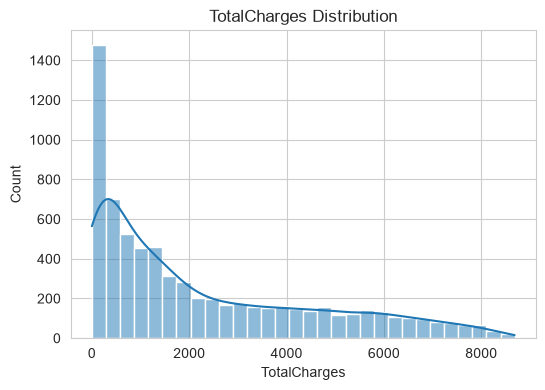

In [40]:
# Now that TotalCharges is properly numeric, visualize its distribution
# (mirrors what we did earlier for tenure and MonthlyCharges)
plt.figure(figsize=(6, 4))
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title('TotalCharges Distribution')
plt.show()

## Observation: TotalCharges is right-skewed, as expected

`TotalCharges` shows a large concentration of customers near $0-500, with a
long tail extending out to ~$8,000+. This matches the earlier finding that
`tenure` is bimodal with a large cluster of very new customers — since
TotalCharges accumulates with tenure, new customers naturally cluster near
zero, while the tail represents long-tenured, high-total-spend customers.
This is consistent with, not a new insight beyond, the tenure-TotalCharges
correlation (0.83) found earlier.

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


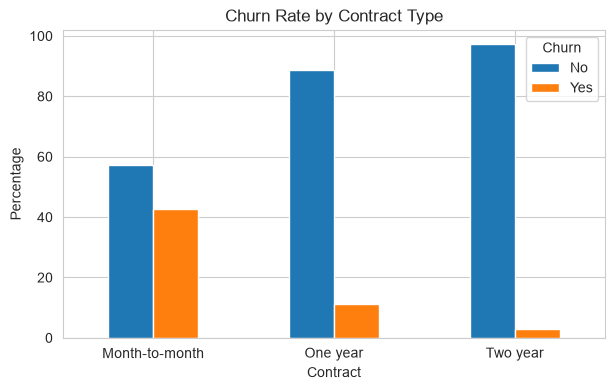

In [35]:
# Cross-tabulate Contract type against Churn, normalized by row (i.e. percentages within each contract type)
# normalize='index' means: for each Contract type, show what % churned vs stayed
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn)

# Visualize it as a grouped bar chart
contract_churn.plot(kind='bar', figsize=(7,4))
plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

## Finding: Contract type is strongly associated with churn

Churn rate by contract type:
- Month-to-month: ~42.7% churn
- One year: ~11.3% churn
- Two year: ~2.8% churn

**Why this matters:** This is one of the strongest patterns in the dataset
so far — churn drops sharply as contract commitment length increases.
This makes business sense: month-to-month customers face no penalty or
friction for leaving, while one/two-year contracts likely involve either
a cancellation cost or simply a customer who has already shown intent to
stay long-term by signing up for one.

**Implication for modeling:** `Contract` is likely to be one of the most
important predictive features in this dataset — we should pay attention
to its feature importance once we get to model training.

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


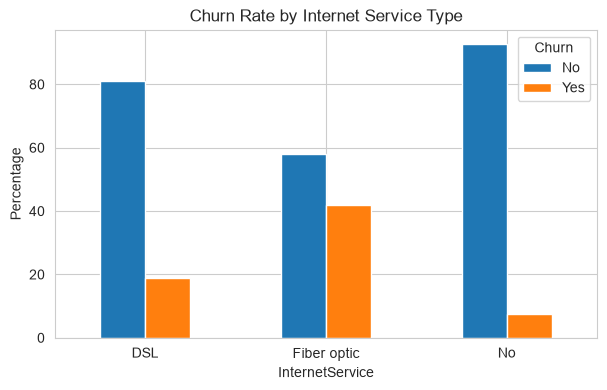

In [36]:
# Same crosstab approach as Contract, but for InternetService
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(internet_churn)

internet_churn.plot(kind='bar', figsize=(7,4))
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

## Finding: Fiber optic customers churn at more than double the rate of DSL

Churn rate by internet service type:
- DSL: ~19.0% churn
- Fiber optic: ~41.9% churn
- No internet service: ~7.4% churn

**Why this matters:** Fiber optic customers churn more than twice as often
as DSL customers. Combined with the earlier finding that higher
MonthlyCharges correlates with churn, cost is a plausible contributing
factor (fiber is typically the pricier tier). However, a 2x+ gap is large
enough that cost alone likely isn't the full explanation — this may
interact with contract type or service satisfaction. Worth investigating
whether fiber customers disproportionately have month-to-month contracts.

**Note:** "No internet service" customers are a fundamentally different
group (phone-only customers), so their low churn isn't directly comparable
to DSL vs Fiber.

In [37]:
# Cross-tab InternetService against Contract type (not Churn this time)
# normalize='index' shows what % of each internet service type falls into each contract type
internet_contract = pd.crosstab(df['InternetService'], df['Contract'], normalize='index') * 100
print(internet_contract)

Contract         Month-to-month   One year   Two year
InternetService                                      
DSL                   50.516316  23.543990  25.939694
Fiber optic           68.733850  17.409561  13.856589
No                    34.338139  23.853211  41.808650


## Follow-up: Fiber optic customers disproportionately have month-to-month contracts

% of each internet service type on each contract:
- DSL: 50.5% month-to-month, 23.5% one year, 25.9% two year
- Fiber optic: 68.7% month-to-month, 17.4% one year, 13.9% two year
- No internet: 34.3% month-to-month, 23.9% one year, 41.8% two year

**Why this matters:** Fiber optic customers are on month-to-month contracts
much more often than DSL customers (68.7% vs 50.5%). Since we already know
month-to-month contracts churn far more than longer contracts, this means
the high Fiber optic churn rate is at least partly explained by contract
type, not internet technology alone. This is a good example of confounding
between two features — Fiber's high churn isn't purely about being fiber,
it's also about who tends to choose fiber (less committed, shorter-contract
customers).

**Implication for modeling:** `Contract` and `InternetService` are
correlated with each other, not just with `Churn` independently. This is
worth keeping in mind for later — when we get to feature importance or
multicollinearity checks, this relationship may show up.

In [38]:
# List the remaining categorical columns we haven't checked individually yet
# (excluding customerID which is just an identifier, and ones we already did)
remaining_cats = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                   'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
                   'PaymentMethod']

# Loop through each column, print its churn rate breakdown
for col in remaining_cats:
    print(f"--- {col} ---")
    print(pd.crosstab(df[col], df['Churn'], normalize='index') * 100)
    print()

--- gender ---
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

--- SeniorCitizen ---
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261

--- Partner ---
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

--- Dependents ---
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

--- PhoneService ---
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

--- MultipleLines ---
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

--- OnlineSecurity ---
Churn    

## Finding: Scanning remaining categorical features

Most features (gender, PhoneService, MultipleLines) showed negligible
difference in churn rate between categories (<2-3 points gap) — these are
likely weak predictors.

A few stood out:

**PaymentMethod**: Electronic check customers churn at 45.3%, roughly
2.5-3x higher than every other payment method (15-19%). This is the
single sharpest categorical split found in the dataset besides Contract
and InternetService. Possibly linked to customer profile (e.g. those who
haven't set up autopay may also be less "locked in" overall) — worth
remembering as a strong candidate feature.

**Add-on services (OnlineSecurity, OnlineBackup, DeviceProtection,
TechSupport)**: All four show the same pattern — customers without the
add-on churn roughly 2-3x more than customers with it (e.g. OnlineSecurity:
41.8% churn without vs 14.6% with). This suggests customers who invest in
more services/support are more "embedded" in the product and less likely
to leave. "No internet service" customers churn least of all in each case,
but that's because they're a separate, phone-only customer base, not
because lacking add-ons is protective for them.

**Household stability (Partner, Dependents, SeniorCitizen)**: Customers
with a partner or dependents churn less (~20-32% gap), and senior citizens
churn more (41.7% vs 23.6%) than non-seniors. Suggests household/life-stage
factors play a secondary but real role.

**Implication for modeling:** Contract, InternetService, PaymentMethod, and
the four add-on service columns look like the strongest categorical
predictors so far. gender, PhoneService, and MultipleLines look weak and
may contribute little — worth watching their feature importance later
rather than assuming now they should be dropped.

                  tenure  MonthlyCharges  TotalCharges  Churn_numeric
tenure          1.000000        0.247900      0.826178      -0.352229
MonthlyCharges  0.247900        1.000000      0.651174       0.193356
TotalCharges    0.826178        0.651174      1.000000      -0.198324
Churn_numeric  -0.352229        0.193356     -0.198324       1.000000


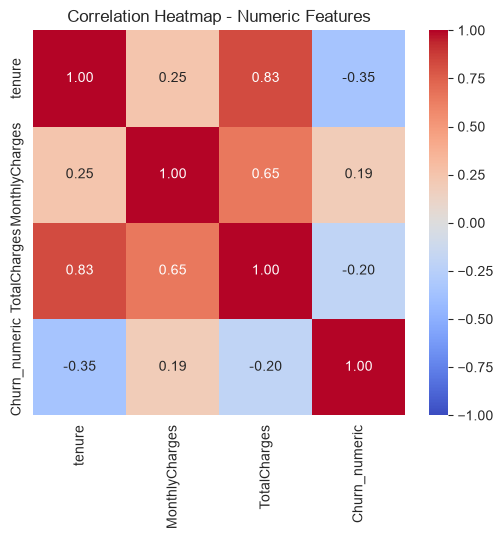

In [39]:
# Select only the numeric columns relevant to churn analysis
# We also convert Churn itself to 0/1 so we can include it in the correlation matrix —
# this lets us see numerically how strongly each feature correlates with churn
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn_numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Compute pairwise correlation coefficients (Pearson correlation by default)
corr_matrix = numeric_df.corr()
print(corr_matrix)

# Visualize as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

## Finding: Correlation confirms tenure as the stronger numeric predictor

Correlation with Churn (numeric, 0=No, 1=Yes):
- tenure: -0.35 (moderate negative — longer tenure, less churn)
- MonthlyCharges: +0.19 (weak-moderate positive — higher charges, more churn)
- TotalCharges: -0.20 (weak-moderate negative)

**Why this matters:** tenure is a meaningfully stronger linear predictor of
churn than MonthlyCharges. This is consistent with the boxplot findings
earlier, but now we have the actual strength, not just direction.

**Note for later:** tenure and TotalCharges are strongly correlated with
each other (0.83). This is expected — longer-tenured customers naturally
accumulate higher total charges, it's not a new insight about churn itself.
But high correlation *between features* (not with the target) is called
multicollinearity, and it's worth remembering for Phase 3: some models
(like linear/logistic regression) can get unstable coefficients when two
input features are this strongly correlated. Tree-based models (Random
Forest, XGBoost) are largely unaffected by this, so it matters more for
which model type we choose than whether we can use these features at all.

MonthlyCharges: 0 potential outliers (bounds: -46.02 to 171.38)
TotalCharges: 0 potential outliers (bounds: -4683.52 to 8868.67)


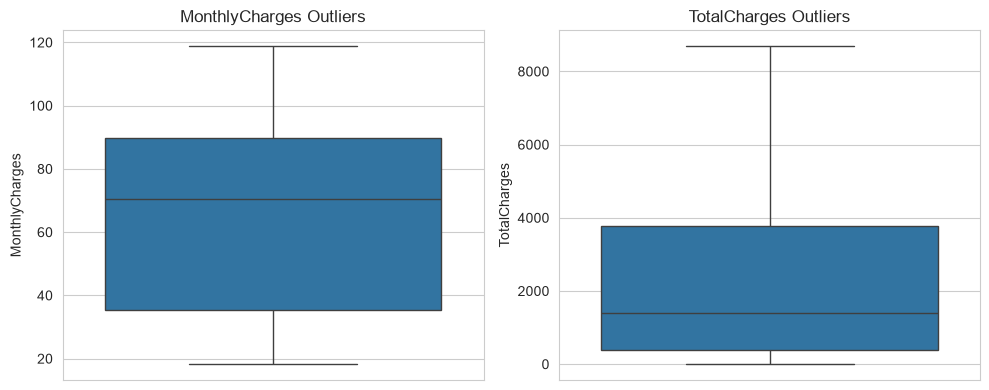

In [41]:
# IQR-based outlier check — a standard, simple method:
# Anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is flagged as a potential outlier
for col in ['MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} potential outliers (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

# Visual check with boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['MonthlyCharges'], ax=axes[0])
axes[0].set_title('MonthlyCharges Outliers')
sns.boxplot(y=df['TotalCharges'], ax=axes[1])
axes[1].set_title('TotalCharges Outliers')
plt.tight_layout()
plt.show()

## Finding: No statistical outliers detected by IQR method

Both MonthlyCharges (bounds: -46 to 171) and TotalCharges (bounds: -4684 to
8869) returned 0 outliers by the standard 1.5×IQR rule.

**Why this happened:** This doesn't mean the data has no skew — we already
established TotalCharges is right-skewed. It means the skew itself widened
the IQR bounds enough that even the largest real values (long-tenured,
high-paying customers) fall within them. The IQR method is calibrated
assuming a roughly symmetric distribution; on a skewed one, it becomes less
sensitive to the very tail it's meant to catch.

**Conclusion:** There are no data-entry errors or impossible values here
(e.g. negative charges, charges in the millions) — both columns behave like
real-world billing data. No rows need to be removed or capped for this
dataset.

# EDA Summary — Key Findings

**Dataset:** 7043 customers, 21 columns, no true missing values (one hidden
issue found and fixed — see below).

## Target variable
- Churn is imbalanced: 73.5% No, 26.5% Yes.
- Accuracy alone will be a misleading metric; will prioritize precision,
  recall, F1, and ROC-AUC in later phases. May need class balancing
  (class weights or SMOTE) during training.

## Data quality
- `TotalCharges` was loaded as a string due to 11 rows containing a blank
  space instead of a number. All 11 had tenure=0 (brand new customers).
  Fixed by converting to numeric and filling with 0.
- Outlier check (IQR method) on MonthlyCharges and TotalCharges found 0
  outliers in both — the right-skew of TotalCharges widens the IQR bounds
  enough that even the highest real values fall within them. No data
  errors or impossible values found; no rows need removal.

## Strongest predictors identified
1. **Contract type** — churn drops sharply with longer commitment
   (Month-to-month 42.7% → One year 11.3% → Two year 2.8%).
2. **InternetService** — Fiber optic churns at 41.9% vs DSL 19.0%, but this
   is partly confounded by Fiber customers being disproportionately
   month-to-month (68.7% vs DSL's 50.5%).
3. **PaymentMethod** — Electronic check churns at 45.3%, far above all
   other methods (15-19%).
4. **Add-on services** (OnlineSecurity, OnlineBackup, DeviceProtection,
   TechSupport) — lacking any of these roughly doubles/triples churn risk
   compared to having them.
5. **tenure** (correlation -0.35) and **MonthlyCharges** (correlation +0.19)
   — newer, higher-paying customers churn more.

## Weaker / likely low-impact features
gender, PhoneService, MultipleLines showed negligible churn rate
differences (<3 points) across categories.

## Things to carry into later phases
- tenure and TotalCharges are highly correlated (0.83) — relevant for model
  choice (linear models sensitive to multicollinearity, tree-based models
  are not).
- Contract and InternetService are correlated with each other, not just
  independently with churn — a reminder that single-variable EDA findings
  can be confounded.
- Class imbalance (73.5/26.5) needs to be addressed in Phase 3 (modeling),
  not Phase 2 (preprocessing) — handled at training time, not by deleting
  data.
- `SeniorCitizen` is already encoded as 0/1 (unlike other Yes/No columns
  which are strings) — no encoding needed for this column in Phase 2.

## Next step
Phase 2: feature engineering and preprocessing — encode categoricals,
finalize train/test split, prepare data for modeling.

## Phase 2 Planning: Column Classification

In [1]:
# Binary categorical columns (Yes/No)
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

# Nominal categorical columns (3+ categories, no natural order)
nominal_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaymentMethod"
]

# Ordinal categorical columns (have a natural order)
ordinal_cols = [
    "Contract"
]

print("Binary:", binary_cols)
print("Nominal:", nominal_cols)
print("Ordinal:", ordinal_cols)

Binary: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Nominal: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']
Ordinal: ['Contract']
